# Generating plots for the paper from the Milgadara demonstration

## Purpose
After running PaddockTS for the Milgadara case study , using both the user-provided and auto-generated paddock boundaries, this notebook shows how to read in the outputs of paddockts for more basic downstreama analyses. 

## PaddockTS run:
This notebook uses the outputs of PaddockTS run for the same query area and time range, in both the auto-segmentation mode and user-provided paddocks mode. Suggested to complete this PaddockTS run before running the notebook.

## Setup

In [1]:
from pathlib import Path
import os

# Move from downstream/ to repository root
repo_root = Path.cwd().parent
os.chdir(repo_root)

print("Working directory:", Path.cwd())

Working directory: /Users/johnburley/scratch/paddock-ts-local


### Establish variables

In [2]:
from pathlib import Path
import json

from PaddockTS.config import config


# PaddockTS run identifier
stub = "Milgadara_2018-25"

# User-provided paddocks
user_paddocks_path = Path(
    "artifacts/Milgadara_paddock-polygons_2024-12-17_12-45-58.json"
)

# Existing PaddockTS directories
paddockts_tmp = Path(config.tmp_dir) / stub
paddockts_out = Path(config.out_dir) / stub

# Outputs created by this notebook
#outpath = paddockts_out / "Case_study_figures"
outpath = Path("manuscript/figures")
outpath.mkdir(parents=True, exist_ok=True)


def get_query_from_stub(stub, registry_path=None):
    """Look up an existing PaddockTS query record by stub."""
    if registry_path is None:
        registry_path = Path(config.out_dir) / "queries.json"

    with open(registry_path) as f:
        registry = json.load(f)

    for bbox_hash, entry in registry.items():
        for query_record in entry["queries"]:
            if query_record["stub"] == stub:
                return {
                    "bbox_hash": bbox_hash,
                    "bbox": entry["bbox"],
                    **query_record,
                }

    raise ValueError(f"No query found with stub: {stub}")


query_info = get_query_from_stub(stub)
query_info

{'bbox_hash': '4061fa8fd4c1436da3c5aecefe76cfc2c6bc55c845f33ba0747fcbd174687a39',
 'bbox': [148.463559, -34.427456, 148.508107, -34.36811],
 'stub': 'Milgadara_2018-25',
 'start': '2018-01-01',
 'end': '2025-12-31',
 'time_hash': '6ed291277644c407946e05f65367e9d3fc2276d5f4ac6827646bd840a84cd5cf',
 'created_at': '2026-08-11T15:21:42.644487Z',
 'last_run_at': '2026-08-13T20:46:27.273614Z'}

In [3]:
# Cached AOI/query directory
query_cache = (
    Path(config.tmp_dir)
    / "aoi"
    / query_info["bbox_hash"]
    / query_info["time_hash"]
)

# Auto-generated SAMGeo paddock boundaries
auto_paddocks_path = query_cache / "sam_paddocks.gpkg"

# Raw SAMGeo output before PaddockTS filtering
auto_paddocks_raw_path = query_cache / "sam_raw.gpkg"

In [4]:
assert user_paddocks_path.exists(), user_paddocks_path
assert paddockts_tmp.exists(), paddockts_tmp
assert paddockts_out.exists(), paddockts_out
assert auto_paddocks_path.exists(), auto_paddocks_path


### Figure 2: paddock boundaries

In [5]:
## Clean up the two polygon sets

import geopandas as gpd

min_area_ha = 5

auto_paddocks = gpd.read_file(auto_paddocks_path)
user_features = gpd.read_file(user_paddocks_path)

# Keep only polygon features classified as user paddocks
user_paddocks = user_features[
    (user_features["type"] == "paddock")
    & user_features.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()

# Counts before area filtering
n_user_before = len(user_paddocks)
n_auto_before = len(auto_paddocks)

# Remove small paddocks
user_paddocks = user_paddocks[
    user_paddocks["area_hectares"] >= min_area_ha
].copy()

auto_paddocks = auto_paddocks[
    auto_paddocks["area_ha"] >= min_area_ha
].copy()

# Reset dataframe indices only — paddock IDs remain unchanged
user_paddocks = user_paddocks.reset_index(drop=True)
auto_paddocks = auto_paddocks.reset_index(drop=True)

# Report
print(f"Minimum paddock area: {min_area_ha} ha")
print(
    f"User paddocks: {len(user_paddocks)} retained "
    f"({n_user_before - len(user_paddocks)} dropped)"
)
print(
    f"Auto paddocks: {len(auto_paddocks)} retained "
    f"({n_auto_before - len(auto_paddocks)} dropped)"
)

Minimum paddock area: 5 ha
User paddocks: 34 retained (8 dropped)
Auto paddocks: 66 retained (0 dropped)


In [6]:
auto_paddocks


,value,area_ha,compactness,paddock,geometry
0,255.0,141.821003,0.212734,1,"POLYGON ((14324720 -4136760, 14324720 -4136790..."
1,255.0,51.802356,0.380285,2,"POLYGON ((14326390 -4137380, 14326390 -4137390..."
2,255.0,44.994505,0.461009,3,"POLYGON ((14325820 -4134600, 14325820 -4134610..."
3,255.0,44.695116,0.459856,4,"POLYGON ((14328130 -4132640, 14328130 -4132650..."
4,255.0,42.985844,0.491409,5,"POLYGON ((14328920 -4133320, 14328920 -4133330..."
...,...,...,...,...,...
61,255.0,6.317865,0.342090,62,"POLYGON ((14327100 -4134290, 14327100 -4134300..."
62,255.0,6.257931,0.397286,63,"POLYGON ((14328300 -4136890, 14328300 -4136900..."
63,255.0,6.137989,0.461422,64,"POLYGON ((14328830 -4137540, 14328830 -4137550..."
64,255.0,5.817978,0.341856,65,"POLYGON ((14325710 -4136160, 14325710 -4136170..."


In [7]:
## Read the Fourier Transform 3-band image that was input to sam geo

from pathlib import Path
import rasterio
import numpy as np
from rasterio.plot import plotting_extent

fourier_path = query_cache / "preseg.tif"

with rasterio.open(fourier_path) as src:
    print("Bands:", src.count)
    print("Dtype:", src.dtypes)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)

    fourier = src.read([1, 2, 3])
    fourier_extent = plotting_extent(src)
    fourier_crs = src.crs

fourier_rgb = np.moveaxis(fourier, 0, -1)

print(fourier_rgb.shape)
print(fourier_rgb.min(), fourier_rgb.max())

Bands: 3
Dtype: ('uint8', 'uint8', 'uint8')
CRS: EPSG:6933
Bounds: BoundingBox(left=14324690.0, bottom=-4138380.0, right=14329000.0, top=-4132090.0)
(629, 431, 3)
0 255


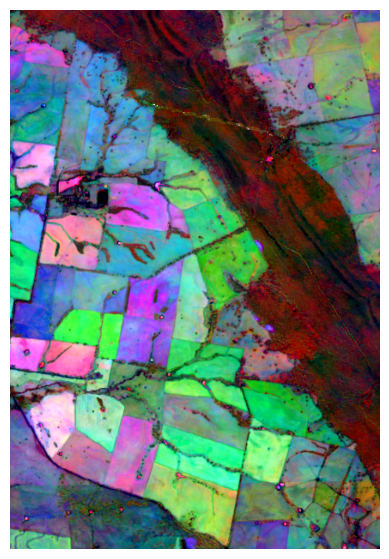

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def percentile_stretch(rgb, lower=2, upper=98):
    """Stretch each RGB band independently between percentile limits."""
    
    stretched = np.zeros_like(rgb, dtype=float)

    for band in range(3):
        x = rgb[..., band].astype(float)

        lo, hi = np.nanpercentile(x, [lower, upper])

        stretched[..., band] = np.clip(
            (x - lo) / (hi - lo),
            0,
            1,
        )

    return stretched


fourier_rgb_stretched = percentile_stretch(
    fourier_rgb,
    lower=2,
    upper=98,
)

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    fourier_rgb_stretched,
    extent=fourier_extent,
    origin="upper",
)

ax.set_axis_off()
plt.show()

In [9]:
# ### Download a high-res aerial image (only need to run once)

# import contextily as cx
# from pathlib import Path

# user_paddocks_web = user_paddocks.to_crs(epsg=3857)

# NSW_IMAGERY = (
#     "https://maps.six.nsw.gov.au/arcgis/rest/services/"
#     "public/NSW_Imagery/MapServer/tile/{z}/{y}/{x}"
# )

# aerial_path = Path("artifacts/Milgadara_NSW_imagery_z15.tif")

# west, south, east, north = user_paddocks_web.total_bounds

# cx.bounds2raster(
#     west,
#     south,
#     east,
#     north,
#     aerial_path,
#     zoom=15,
#     source=NSW_IMAGERY,
# )

In [10]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

aerial_path = Path("artifacts/Milgadara_NSW_imagery_z15.tif")

# Reproject aerial imagery directly onto the Fourier raster grid
with rasterio.open(aerial_path) as aerial_src, \
     rasterio.open(fourier_path) as fourier_src:

    aerial_fourier = np.zeros(
        (3, fourier_src.height, fourier_src.width),
        dtype=np.uint8
    )

    for band in range(3):
        reproject(
            source=rasterio.band(aerial_src, band + 1),
            destination=aerial_fourier[band],
            src_transform=aerial_src.transform,
            src_crs=aerial_src.crs,
            dst_transform=fourier_src.transform,
            dst_crs=fourier_src.crs,
            resampling=Resampling.bilinear,
        )

aerial_fourier_rgb = np.moveaxis(aerial_fourier, 0, -1)

In [11]:
print(fourier_crs)

EPSG:6933


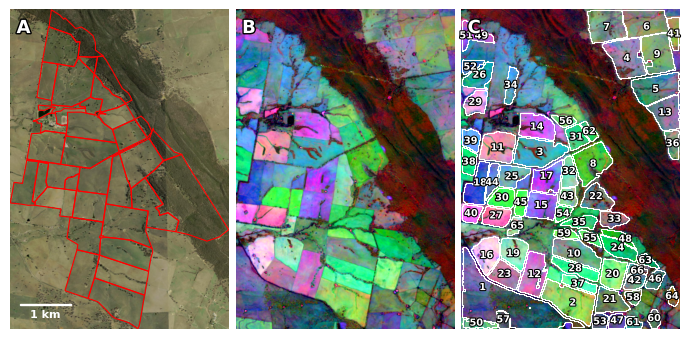

In [12]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Settings
# ---------------------------------------------------------------------

show_auto_labels = True
auto_label_fontsize = 7

# ---------------------------------------------------------------------
# Reproject paddocks to match Fourier CRS
# ---------------------------------------------------------------------

user_paddocks_fourier = user_paddocks.to_crs(fourier_crs)
auto_paddocks_fourier = auto_paddocks.to_crs(fourier_crs)

# ---------------------------------------------------------------------
# Build figure
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    ncols=3,
    figsize=((6.7, 3.9)),
)

# ============================================================
# A. Aerial imagery + user paddocks
# ============================================================

ax = axes[0]

ax.imshow(
    aerial_fourier_rgb,
    extent=fourier_extent,
    origin="upper",
)

user_paddocks_fourier.boundary.plot(
    ax=ax,
    color="red",
    linewidth=0.8,
    zorder=3,
)

# Scale bar
scalebar = AnchoredSizeBar(
    ax.transData,
    1000,                   # 1000 map units = 1 km
    "1 km",
    loc="lower left",
    pad=0.4,
    borderpad=0.5,
    sep=3,
    frameon=False,
    size_vertical=20,
    color="white",
    fontproperties=fm.FontProperties(size=8, weight="semibold"),
)

ax.add_artist(scalebar)
ax.set_axis_off()


# ============================================================
# B. Fourier false-colour image
# ============================================================

ax = axes[1]

ax.imshow(
    fourier_rgb_stretched,
    extent=fourier_extent,
    origin="upper",
)

ax.set_axis_off()


# ============================================================
# C. Fourier image + auto paddocks
# ============================================================

ax = axes[2]

ax.imshow(
    fourier_rgb_stretched,
    extent=fourier_extent,
    origin="upper",
)

auto_paddocks_fourier.boundary.plot(
    ax=ax,
    color="white",
    linewidth=0.8,
    zorder=3,
)

# Optional integer paddock labels
if show_auto_labels:
    for _, row in auto_paddocks_fourier.iterrows():
        point = row.geometry.representative_point()

        ax.text(
            point.x,
            point.y,
            str(row["paddock"]),
            ha="center",
            va="center",
            fontsize=auto_label_fontsize,
            fontweight="semibold",
            color="white",
            zorder=5,
            path_effects=[
                pe.withStroke(linewidth=1.5, foreground="black")
            ],
        )

ax.set_axis_off()


# ============================================================
# Panel labels
# ============================================================

for ax, label in zip(axes, ["A", "B", "C"]):
    ax.text(
        0.03,
        0.97,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=13,
        fontweight="bold",
        color="white",
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ],
        zorder=10,
    )

# ---------------------------------------------------------------------
# Final layout
# ---------------------------------------------------------------------

plt.subplots_adjust(
    wspace=0.03,
    left=0,
    right=1,
    top=1,
    bottom=0,
)

plt.show()

In [13]:
fig.savefig(
    outpath / "Figure2_Milgadara_segmentation.svg",
    bbox_inches="tight",
    pad_inches=0.02,
)

### Read in the resampled, interpolated, smoothed paddock time series. 
For Figure 3 (paddock-level vegetation dynamics)

In [14]:
import xarray as xr

paddockts_smoothed_auto = xr.open_zarr(
    paddockts_tmp / "sam_paddocks_timeseries_smoothed.zarr"
)

# Match polygon ID datatype
paddockts_smoothed_auto = paddockts_smoothed_auto.assign_coords(
    paddock=paddockts_smoothed_auto["paddock"].astype(int)
)

print(paddockts_smoothed_auto)

<xarray.Dataset> Size: 3MB
Dimensions:           (paddock: 66, time: 292)
Coordinates:
  * paddock           (paddock) int64 528B 1 2 3 4 5 6 7 ... 61 62 63 64 65 66
  * time              (time) datetime64[ns] 2kB 2018-01-03 ... 2025-12-22
    spatial_ref       int32 4B ...
Data variables: (12/20)
    bg                (paddock, time) float64 154kB dask.array<chunksize=(66, 292), meta=np.ndarray>
    CAI               (paddock, time) float64 154kB dask.array<chunksize=(66, 292), meta=np.ndarray>
    CFI               (paddock, time) float64 154kB dask.array<chunksize=(66, 292), meta=np.ndarray>
    nbart_blue        (paddock, time) float64 154kB dask.array<chunksize=(66, 292), meta=np.ndarray>
    nbart_green       (paddock, time) float64 154kB dask.array<chunksize=(66, 292), meta=np.ndarray>
    nbart_nir_1       (paddock, time) float64 154kB dask.array<chunksize=(66, 292), meta=np.ndarray>
    ...                ...
    NDVI              (paddock, time) float64 154kB dask.array<chunk

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def fractional_cover_rgb(ds):
    """Convert bg, pv and npv fractional cover to an RGB array."""

    rgb = np.stack([
        ds["bg"].values,   # red
        ds["pv"].values,   # green
        ds["npv"].values,  # blue
    ], axis=-1)

    # Fractional cover is stored as percentages
    if np.nanmax(rgb) > 1.5:
        rgb = rgb / 100

    return np.clip(rgb, 0, 1)

In [16]:
def plot_fractional_cover_heatmap(
    ds,
    paddocks=None,
    figsize=((6.7, 3.9)),
    show_paddock_labels=False,
):
    """Plot multi-year paddock fractional-cover trajectories as RGB."""

    # Select paddocks, preserving the supplied order
    if paddocks is not None:
        ds = ds.sel(paddock=paddocks)

    rgb = fractional_cover_rgb(ds)

    times = ds["time"].values
    paddock_ids = ds["paddock"].values

    # Convert dates to matplotlib coordinates
    x = mdates.date2num(times)

    fig, ax = plt.subplots(figsize=figsize)

    ax.imshow(
        rgb,
        aspect="auto",
        interpolation="nearest",
        extent=[
            x[0],
            x[-1],
            len(paddock_ids) - 0.5,
            -0.5,
        ],
    )

    # Date axis
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Paddock axis
    if show_paddock_labels:
        ax.set_yticks(np.arange(len(paddock_ids)))
        ax.set_yticklabels(paddock_ids)
        ax.set_ylabel("Paddock")
    else:
        ax.set_yticks([])

    ax.set_xlabel("Year")

    plt.tight_layout()

    return fig, ax

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]


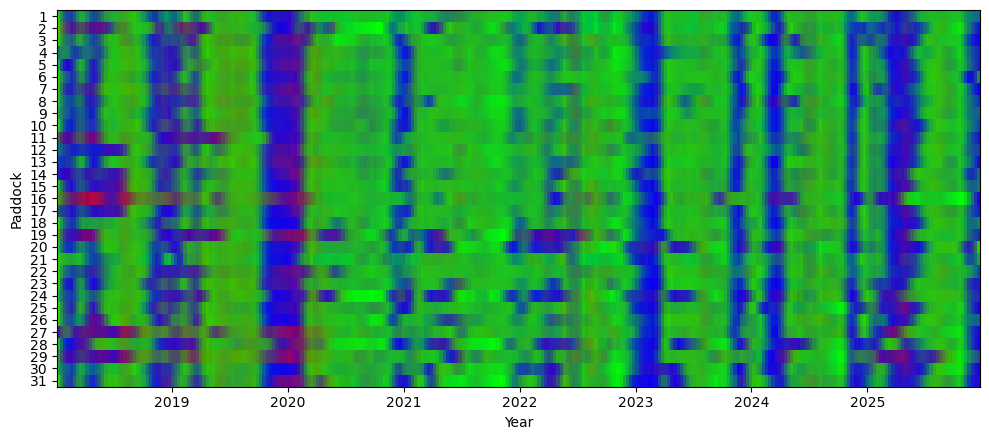

In [17]:
paddocks_to_plot = auto_paddocks["paddock"].iloc[:31].to_numpy()

print(paddocks_to_plot)

fig, ax = plot_fractional_cover_heatmap(
    paddockts_smoothed_auto,
    paddocks=paddocks_to_plot,
    figsize=((10, 4.5)),
    show_paddock_labels=True,
)

plt.show()

In [18]:
fig.savefig(
    outpath / "Figure3_paddocktimeseries_Milgadara_auto_largest31_vegfrac.svg",
    bbox_inches="tight",
    pad_inches=0.02,
)

75th percentile BG threshold: 0.181


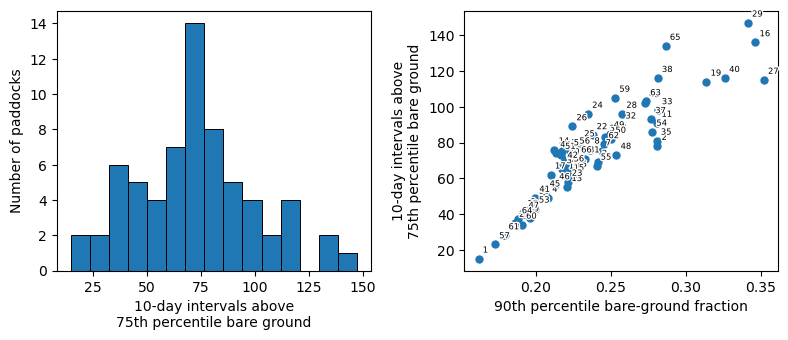

In [29]:
## Plot paddock-level drought exposure as frequency of bare ground versus severity of barest moment. 

# Global 75th-percentile bare-ground threshold
bg_threshold = float(
    paddockts_smoothed_auto["bg"]
    .quantile(0.75)
    .compute()
)

print(f"75th percentile BG threshold: {bg_threshold:.3f}")

# Number of 10-day intervals above the global threshold, per paddock
bg_exceedance_count = (
    (paddockts_smoothed_auto["bg"] > bg_threshold)
    .sum(dim="time")
    .compute()
)

# 90th percentile of bare-ground fraction, per paddock
bg_p90 = (
    paddockts_smoothed_auto["bg"]
    .quantile(0.90, dim="time")
    .compute()
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    ncols=2,
    figsize=(8, 3.5),
)

# A. Distribution of exceedance frequency
ax = axes[0]

ax.hist(
    bg_exceedance_count.values,
    bins=15,
    edgecolor="black",
    linewidth=0.7,
)

ax.set_xlabel(
    "10-day intervals above\n75th percentile bare ground"
)
ax.set_ylabel("Number of paddocks")


# B. Frequency versus severity
ax = axes[1]

ax.scatter(
    bg_p90.values,
    bg_exceedance_count.values,
    s=25,
)

# Label points with paddock ID
for paddock, x, y in zip(
    bg_p90["paddock"].values,
    bg_p90.values,
    bg_exceedance_count.values,
):
    ax.annotate(
        str(int(paddock)),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=6,
        ha="left",
        va="bottom",
        path_effects=[
            pe.withStroke(linewidth=2, foreground="white")
        ],
    )

ax.set_xlabel("90th percentile bare-ground fraction")
ax.set_ylabel(
    "10-day intervals above\n75th percentile bare ground"
)

plt.tight_layout()
plt.show()

In [30]:
fig.savefig(
    outpath / "drough_exposure_paddock_explorer.svg",
    bbox_inches="tight",
    pad_inches=0.02,
)

### Fig 3. the environmental data

In [ ]:
### recreate this figure based on the old one. Still need to find the code

### Read in the paddock-year  time series

For Figure 3 (paddock-level vegetation dynamics)

In [19]:
import re
import xarray as xr


def load_paddockts_years(paddockts_tmp, prefix, paddock_dtype=None):
    """Load yearly PaddockTS datasets as {year: Dataset}. Returns a dict.
    Works for the auto-generated or user-generated time series, just specify"""

    paddockts_tmp = Path(paddockts_tmp)
    datasets = {}

    pattern = re.compile(
        rf"{re.escape(prefix)}_timeseries_(\d{{4}})\.zarr$"
    )

    for path in sorted(paddockts_tmp.glob(f"{prefix}_timeseries_*.zarr")):
        match = pattern.match(path.name)

        # Ignore non-yearly products such as *_smoothed.zarr
        if match is None:
            continue

        year = int(match.group(1))
        ds = xr.open_zarr(path)

        if paddock_dtype is not None and "paddock" in ds.coords:
            ds = ds.assign_coords(
                paddock=ds["paddock"].astype(paddock_dtype)
            )

        datasets[year] = ds

    if not datasets:
        raise FileNotFoundError(
            f"No yearly paddock time series found for '{prefix}' "
            f"in {paddockts_tmp}"
        )

    return datasets

# # examples:
    
# paddockts_years_auto = load_paddockts_years(
#     paddockts_tmp,
#     prefix="sam_paddocks",
#     paddock_dtype=int,
# )

# paddockts_years_user = load_paddockts_years(
#     paddockts_tmp,
#     prefix=user_paddocks_path.stem,
# )

In [20]:
paddockts_years_auto = load_paddockts_years(
    paddockts_tmp,
    prefix="sam_paddocks",
    paddock_dtype=int,
)

# paddockts_years_user = load_paddockts_years(
#     paddockts_tmp,
#     prefix=user_paddocks_path.stem,
# )

In [21]:
assert np.array_equal(
    next(iter(paddockts_years_auto.values()))["paddock"].values,
    auto_paddocks["paddock"].values
)
print("Checked: paddock identifiers match between time series and geopandas df \n==========")
print("data variables:")
print(list(paddockts_years_auto[2020].data_vars))
print(paddockts_years_auto.keys(), "\n==========")
print(paddockts_years_auto[2020])
print("===============\n paddock gpd: \n", auto_paddocks)


Checked: paddock identifiers match between time series and geopandas df 
data variables:
['bg', 'CAI', 'CFI', 'nbart_blue', 'nbart_green', 'nbart_nir_1', 'nbart_nir_2', 'nbart_red', 'nbart_red_edge_1', 'nbart_red_edge_2', 'nbart_red_edge_3', 'nbart_swir_2', 'nbart_swir_3', 'NDTI', 'NDVI', 'NIRv', 'npv', 'oa_fmask', 'observed', 'pv']
dict_keys([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]) 
<xarray.Dataset> Size: 375kB
Dimensions:           (paddock: 66, time: 37)
Coordinates:
  * paddock           (paddock) int64 528B 1 2 3 4 5 6 7 ... 61 62 63 64 65 66
  * time              (time) datetime64[ns] 296B 2020-01-03 ... 2020-12-28
    doy               (time) int64 296B dask.array<chunksize=(37,), meta=np.ndarray>
    spatial_ref       int32 4B ...
Data variables: (12/20)
    bg                (paddock, time) float64 20kB dask.array<chunksize=(66, 37), meta=np.ndarray>
    CAI               (paddock, time) float64 20kB dask.array<chunksize=(66, 37), meta=np.ndarray>
    CFI             

## Extrass

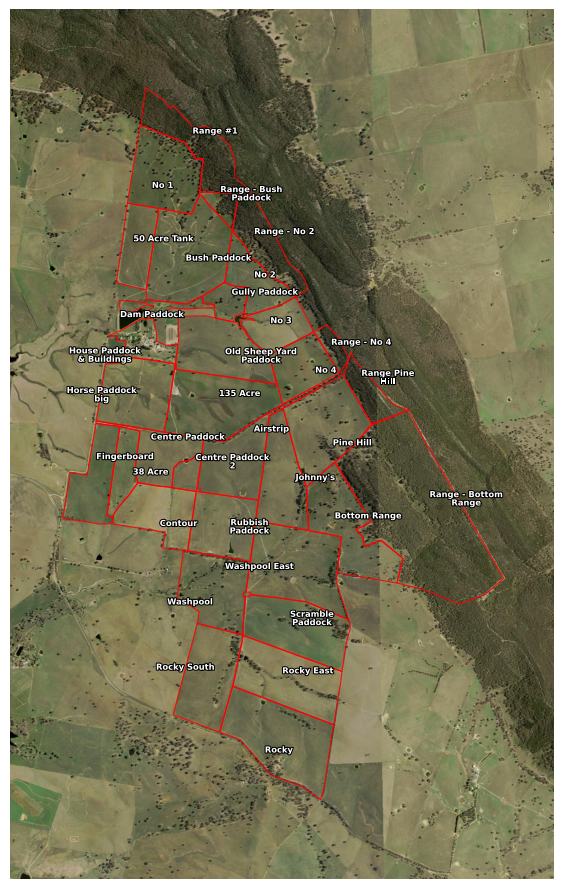

In [22]:
import textwrap

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import rasterio

from adjustText import adjust_text
from pathlib import Path
from rasterio.plot import plotting_extent


# ---------------------------------------------------------------------
# Settings
# ---------------------------------------------------------------------

aerial_path = Path("artifacts/Milgadara_NSW_imagery_z15.tif")

show_labels = True
label_fontsize = 6
label_wrap_width = 14


# ---------------------------------------------------------------------
# Prepare paddocks
# ---------------------------------------------------------------------

# Retain only paddock polygons if the original file contains landmarks etc.
if "type" in user_paddocks.columns:
    paddocks_plot = user_paddocks[
        (user_paddocks["type"] == "paddock")
        & user_paddocks.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
    ].copy()
else:
    paddocks_plot = user_paddocks.copy()


# ---------------------------------------------------------------------
# Load aerial imagery
# ---------------------------------------------------------------------

with rasterio.open(aerial_path) as src:
    aerial = src.read([1, 2, 3])
    aerial_extent = plotting_extent(src)
    aerial_crs = src.crs

aerial_rgb = np.moveaxis(aerial, 0, -1)


# Reproject paddocks to match aerial imagery
paddocks_plot = paddocks_plot.to_crs(aerial_crs)


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 9))

# Aerial image
ax.imshow(
    aerial_rgb,
    extent=aerial_extent,
    origin="upper",
)

# User-provided paddock boundaries
paddocks_plot.boundary.plot(
    ax=ax,
    color="red",
    linewidth=0.8,
    alpha=0.9,
    zorder=3,
)


# ---------------------------------------------------------------------
# Paddock labels
# ---------------------------------------------------------------------

if show_labels:

    texts = []

    for _, row in paddocks_plot.iterrows():

        # Guaranteed to fall within the polygon
        point = row.geometry.representative_point()

        # Wrap long paddock names
        label = "\n".join(
            textwrap.wrap(
                str(row["title"]),
                width=label_wrap_width,
            )
        )

        text = ax.text(
            point.x,
            point.y,
            label,
            fontsize=label_fontsize,
            fontweight="semibold",
            color="white",
            ha="center",
            va="center",
            linespacing=0.9,
            zorder=5,
            path_effects=[
                pe.withStroke(
                    linewidth=1.5,
                    foreground="black",
                )
            ],
        )

        texts.append(text)

    # Move labels to reduce overlap
    adjust_text(
        texts,
        ax=ax,
        only_move={"text": "xy"},
    )


# ---------------------------------------------------------------------
# Final formatting
# ---------------------------------------------------------------------

# Keep exactly the aerial-image extent
ax.set_xlim(aerial_extent[0], aerial_extent[1])
ax.set_ylim(aerial_extent[2], aerial_extent[3])

ax.set_axis_off()

plt.tight_layout()
plt.show()

[29 16 27 40 19 65 38 33 11 63]


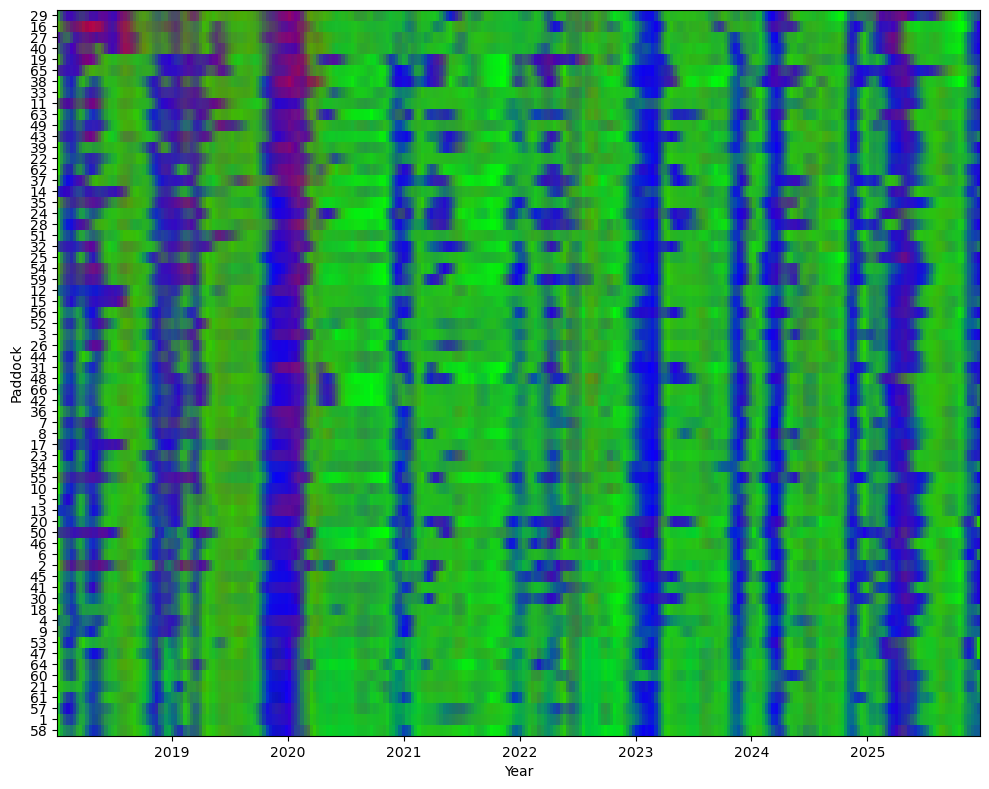

In [23]:
# Order paddocks by descending total bare ground across the full time series
paddocks_by_bg = (
    paddockts_smoothed_auto["bg"]
    .sum(dim="time")
    .sortby(
        paddockts_smoothed_auto["bg"].sum(dim="time"),
        ascending=False
    )
    .paddock
    .values
)

print(paddocks_by_bg[:10])

fig, ax = plot_fractional_cover_heatmap(
    paddockts_smoothed_auto,
    paddocks=paddocks_by_bg,
    figsize=(10, 8),
    show_paddock_labels=True,
)

plt.show()